In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error
import tensorflow as tf
from tensorflow.keras import layers, regularizers
from tensorflow.keras.models import Model
import warnings
warnings.filterwarnings('ignore')

In [2]:
csv_url = 'https://drive.google.com/uc?export=download&id=1hpsqSpfjdqIZWqwd259klQSeaNSe5Trr'
df = pd.read_csv(csv_url)
df['Date'] = pd.to_datetime(df['Date'], format='mixed')
df = df.sort_values('Date').reset_index(drop=True)

In [3]:
features = ['Close', 'Volume USDT', 'RSI', 'MACD_Hist', 'ATR', 'KAMAO']
target_col = 'Close'

df['Close_Rolling_Mean_24'] = df['Close'].rolling(window=24).mean()
df['Close_Rolling_STD_24']  = df['Close'].rolling(window=24).std()
features.extend(['Close_Rolling_Mean_24', 'Close_Rolling_STD_24'])
df = df.dropna().reset_index(drop=True)

WINDOW_SIZE = 48
HORIZON     = 24
BATCH_SIZE  = 64

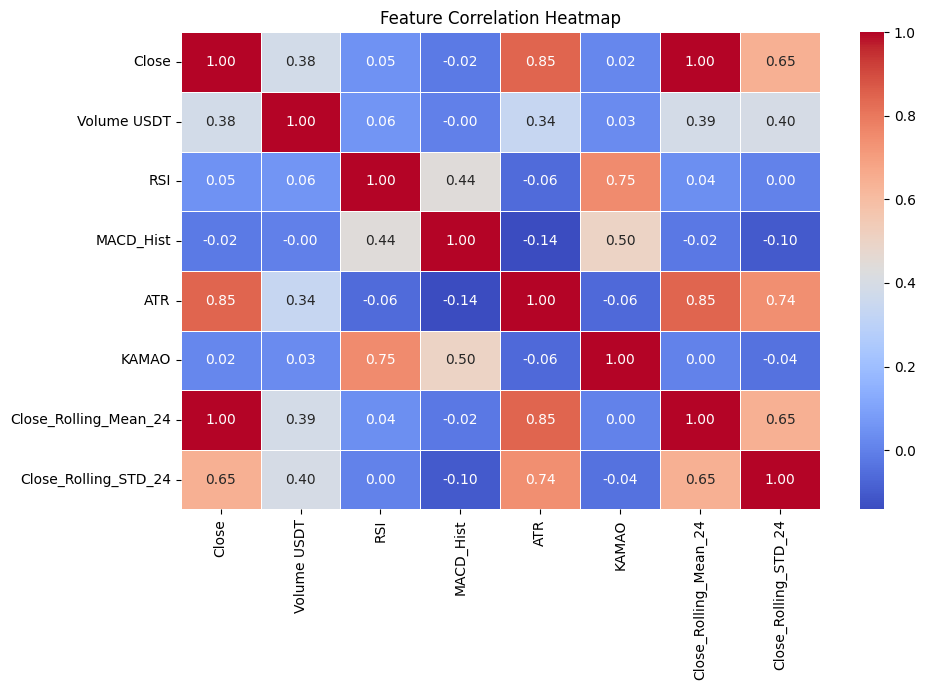

In [4]:
import seaborn as sns

plt.figure(figsize=(10, 7))

corr = df[features].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

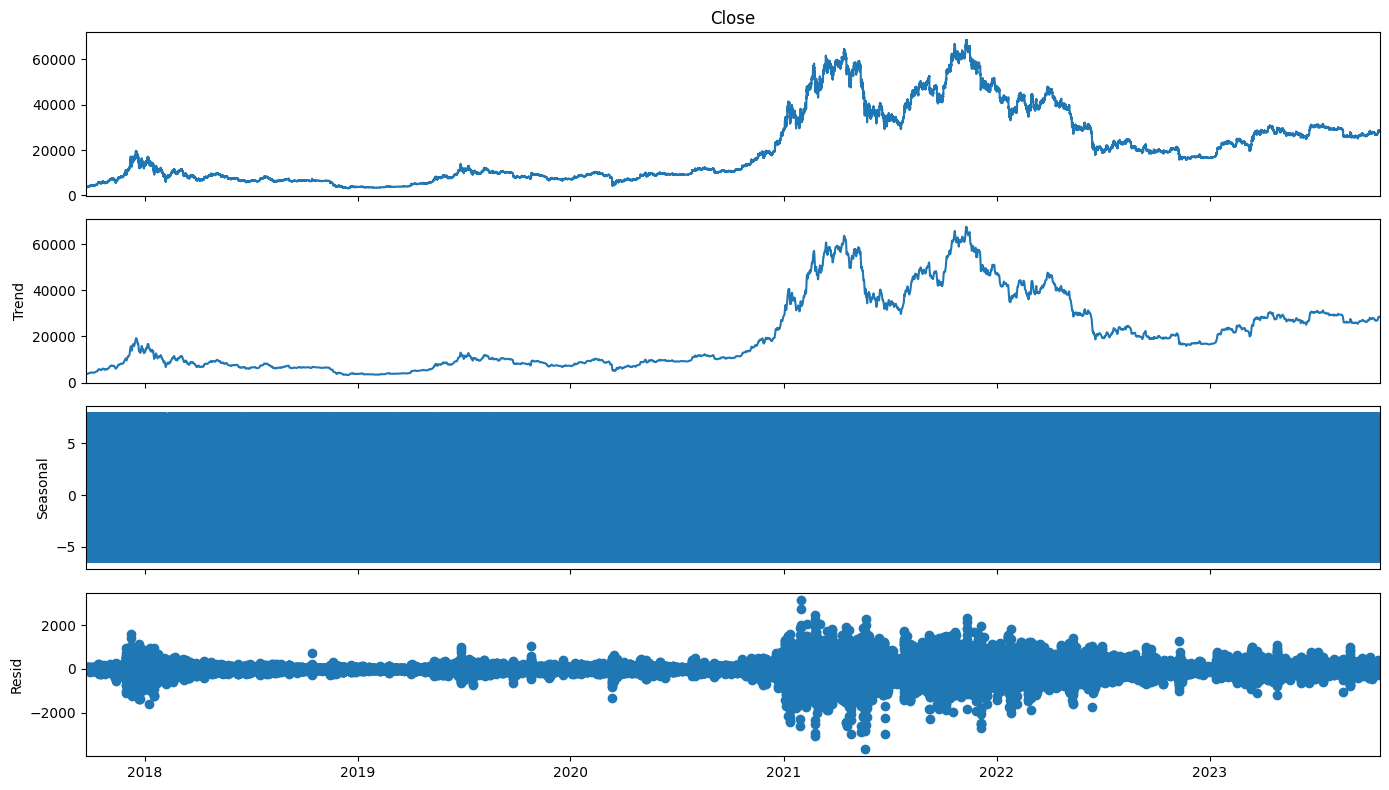

In [5]:
from statsmodels.tsa.seasonal import seasonal_decompose

close_series = df.set_index('Date')['Close']

decomposition = seasonal_decompose(
    close_series,
    model='additive',
    period=24
)

fig = decomposition.plot()
fig.set_size_inches(14, 8)
plt.tight_layout()
plt.show()

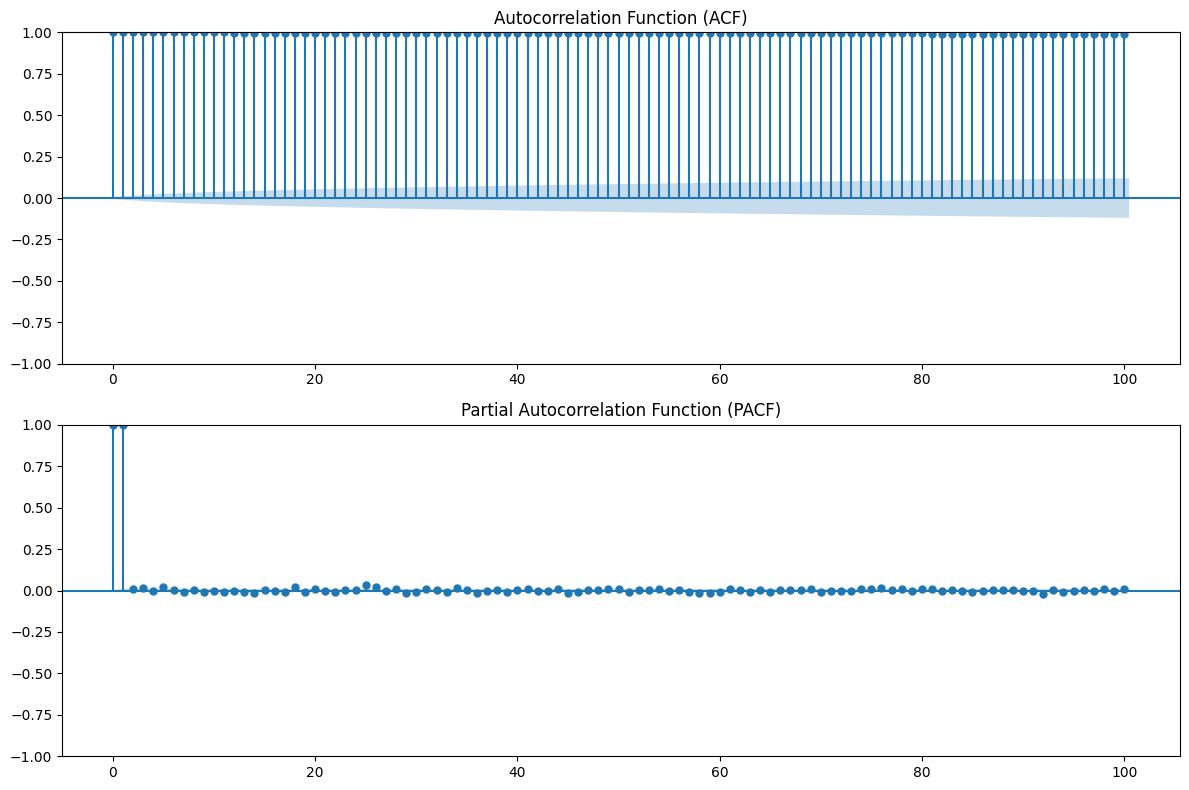

In [6]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

plot_acf(df['Close'], lags=100, ax=axes[0])
axes[0].set_title('Autocorrelation Function (ACF)')

plot_pacf(df['Close'], lags=100, ax=axes[1], method='ywm')
axes[1].set_title('Partial Autocorrelation Function (PACF)')

plt.tight_layout()
plt.show()

In [7]:
n          = len(df)
train_size = int(n * 0.70)
val_size   = int(n * 0.15)
train_df   = df.iloc[:train_size]
val_df     = df.iloc[train_size:train_size+val_size]
test_df    = df.iloc[train_size+val_size:]
print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

Train: 37188 | Val: 7969 | Test: 7970


In [8]:
scaler       = MinMaxScaler()
train_scaled = scaler.fit_transform(train_df[features])
val_scaled   = scaler.transform(val_df[features])
test_scaled  = scaler.transform(test_df[features])
target_index = features.index(target_col)

In [9]:
def create_sequences(data, window_size, horizon, target_index):
    X, y = [], []
    for i in range(window_size, len(data) - horizon):
        X.append(data[i-window_size:i])
        y.append(data[i:i+horizon, target_index])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

X_train, y_train = create_sequences(train_scaled, WINDOW_SIZE, HORIZON, target_index)
X_val,   y_val   = create_sequences(val_scaled,   WINDOW_SIZE, HORIZON, target_index)
X_test,  y_test  = create_sequences(test_scaled,  WINDOW_SIZE, HORIZON, target_index)
print(f"X_train: {X_train.shape} | y_train: {y_train.shape}")

X_train: (37116, 48, 8) | y_train: (37116, 24)


In [10]:
train_dataset = (tf.data.Dataset
    .from_tensor_slices((X_train, y_train))
    .shuffle(2000, reshuffle_each_iteration=True)
    .batch(BATCH_SIZE, drop_remainder=True)
    .cache()
    .prefetch(tf.data.AUTOTUNE))

val_dataset = (tf.data.Dataset
    .from_tensor_slices((X_val, y_val))
    .batch(BATCH_SIZE)
    .cache()
    .prefetch(tf.data.AUTOTUNE))

In [11]:
decoder_train_input = np.zeros((len(y_train), HORIZON, 1), dtype=np.float32)
decoder_val_input   = np.zeros((len(y_val),   HORIZON, 1), dtype=np.float32)
decoder_test_input  = np.zeros((len(y_test),  HORIZON, 1), dtype=np.float32)
decoder_train_input[:, 1:, 0] = y_train[:, :-1]
decoder_val_input[:,   1:, 0] = y_val[:,   :-1]
decoder_test_input[:,  1:, 0] = y_test[:,  :-1]

In [12]:
class CustomDense(layers.Layer):
    def __init__(self, units, activation=None, **kwargs):
        super().__init__(**kwargs)
        self.units = units
        self.activation = tf.keras.activations.get(activation)

    def build(self, input_shape):
        self.w = self.add_weight(
            shape=(input_shape[-1], self.units),
            initializer='glorot_uniform',
            trainable=True,
            name='kernel'
        )

        self.b = self.add_weight(
            shape=(self.units,),
            initializer='zeros',
            trainable=True,
            name='bias'
        )

    def call(self, inputs):
        x = tf.matmul(inputs, self.w) + self.b

        if self.activation is not None:
            x = self.activation(x)

        return x

    def get_config(self):
        config = super().get_config()
        config.update({
            'units': self.units,
            'activation': tf.keras.activations.serialize(self.activation)
        })
        return config

In [13]:
class SwishActivation(layers.Layer):
    def call(self, inputs):
        return inputs * tf.nn.sigmoid(inputs)

    def get_config(self):
        return super().get_config()

In [14]:
class CustomMultiHeadAttention(layers.Layer):
    def __init__(self, d_model, num_heads, **kwargs):
        super().__init__(**kwargs)
        assert d_model % num_heads == 0
        self.num_heads = num_heads
        self.d_model   = d_model
        self.depth     = d_model // num_heads
        self.wq    = layers.Dense(d_model)
        self.wk    = layers.Dense(d_model)
        self.wv    = layers.Dense(d_model)
        self.dense = layers.Dense(d_model)

    def split_heads(self, x, batch_size):
        x = tf.reshape(x, (batch_size, -1, self.num_heads, self.depth))
        return tf.transpose(x, perm=[0, 2, 1, 3])

    def call(self, v, k, q):
        batch_size = tf.shape(q)[0]
        q = self.split_heads(self.wq(q), batch_size)
        k = self.split_heads(self.wk(k), batch_size)
        v = self.split_heads(self.wv(v), batch_size)
        dk     = tf.cast(tf.shape(k)[-1], tf.float32)
        logits = tf.matmul(q, k, transpose_b=True) / tf.math.sqrt(dk)
        attn   = tf.nn.softmax(logits, axis=-1)
        out    = tf.reshape(
            tf.transpose(tf.matmul(attn, v), perm=[0, 2, 1, 3]),
            (batch_size, -1, self.d_model))
        return self.dense(out)

    def get_config(self):
        config = super().get_config()
        config.update({'d_model': self.d_model, 'num_heads': self.num_heads})
        return config

In [15]:
class BaselineLSTM(Model):
    def __init__(self, horizon=24, **kwargs):
        super().__init__(**kwargs)
        self.horizon   = horizon
        self.lstm1     = layers.LSTM(128, return_sequences=True)
        self.bn1       = layers.BatchNormalization()
        self.attention = CustomMultiHeadAttention(d_model=128, num_heads=4)
        self.lstm2     = layers.LSTM(64)
        self.bn2       = layers.BatchNormalization()
        self.dropout   = layers.Dropout(0.3)
        self.dense1    = CustomDense(64, activation='relu')
        self.out_layer = CustomDense(horizon)

    def call(self, inputs, training=False):
        x = self.lstm1(inputs)
        x = self.bn1(x, training=training)
        x = self.attention(x, x, x)
        x = self.lstm2(x)
        x = self.bn2(x, training=training)
        x = self.dropout(x, training=training)
        x = self.dense1(x)
        return self.out_layer(x)

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'horizon': self.horizon})
        return cfg


baseline_model = BaselineLSTM()
optimizer_base = tf.keras.optimizers.Adam(learning_rate=0.001, clipnorm=1.0)

In [16]:
def build_seq2seq_functional():
    encoder_inputs = layers.Input(
        shape=(WINDOW_SIZE, len(features)), name='encoder_input')
    encoder_lstm   = layers.LSTM(128, return_state=True, name='encoder_lstm')
    _, state_h, state_c = encoder_lstm(encoder_inputs)

    decoder_inputs = layers.Input(shape=(HORIZON, 1), name='decoder_input')
    decoder_lstm   = layers.LSTM(
        128, return_sequences=True, return_state=True, name='decoder_lstm')
    decoder_outputs, _, _ = decoder_lstm(
        decoder_inputs, initial_state=[state_h, state_c])

    attention = CustomMultiHeadAttention(d_model=128, num_heads=4)
    x = attention(decoder_outputs, decoder_outputs, decoder_outputs)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    x = CustomDense(64, activation='relu')(x)
    x = SwishActivation()(x)
    outputs = CustomDense(1)(x)

    model = Model(
        inputs=[encoder_inputs, decoder_inputs],
        outputs=outputs,
        name='Seq2Seq_Functional'
    )
    return model

seq2seq_model = build_seq2seq_functional()

In [ ]:
class Seq2SeqTeacherForcing(Model):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.encoder_lstm = layers.LSTM(128, return_state=True)
        self.decoder_lstm = layers.LSTM(
            128, return_sequences=True, return_state=True)
        self.attention    = CustomMultiHeadAttention(d_model=128, num_heads=4)
        self.bn           = layers.BatchNormalization()
        self.dropout      = layers.Dropout(0.3)
        self.dense1       = CustomDense(64, activation='relu')
        self.final_dense  = CustomDense(1)

    def call(self, inputs, training=False):
        encoder_inputs, decoder_inputs = inputs
        _, state_h, state_c = self.encoder_lstm(encoder_inputs)
        dec_out, _, _ = self.decoder_lstm(
            decoder_inputs, initial_state=[state_h, state_c])
        x = self.attention(dec_out, dec_out, dec_out)
        x = self.bn(x, training=training)
        x = self.dropout(x, training=training)
        x = self.dense1(x)
        return self.final_dense(x)

In [18]:
class WeightedMAELoss(tf.keras.losses.Loss):
    def __init__(self):
        super().__init__()
        self.weights = tf.constant(
            np.linspace(1.0, 2.5, HORIZON), dtype=tf.float32)

    def call(self, y_true, y_pred):
        error = tf.abs(
            tf.cast(y_true, tf.float32) - tf.cast(y_pred, tf.float32))
        return tf.reduce_mean(error * self.weights)

loss_fn = WeightedMAELoss()

In [19]:
class EarlyStopping:
    def __init__(self, patience=10, min_delta=1e-5):
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = np.inf
        self.wait = 0
        self.best_weights = None
        self.stop = False

    def __call__(self, val_loss, model):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.wait = 0
            self.best_weights = model.get_weights()
        else:
            self.wait += 1
            if self.wait >= self.patience:
                self.stop = True
                model.set_weights(self.best_weights)
                print("Early stopping. Best weights restored.")

class ReduceLR:
    def __init__(self, optimizer, patience=3, factor=0.5, min_lr=1e-6):
        self.optimizer = optimizer
        self.patience = patience
        self.factor = factor
        self.min_lr = min_lr
        self.best_loss = np.inf
        self.wait = 0

    def __call__(self, val_loss):
        if val_loss < self.best_loss:
            self.best_loss = val_loss
            self.wait = 0
        else:
            self.wait += 1
            if self.wait >= self.patience:
                old_lr = float(self.optimizer.learning_rate)
                new_lr = max(old_lr * self.factor, self.min_lr)
                self.optimizer.learning_rate.assign(new_lr)
                print(f"LR: {old_lr:.2e} → {new_lr:.2e}")
                self.wait = 0

In [20]:
@tf.function
def train_step_base(x_batch, y_batch):
    with tf.GradientTape() as tape:
        pred = baseline_model(x_batch, training=True)
        loss = loss_fn(y_batch, pred)
    grads = tape.gradient(loss, baseline_model.trainable_variables)
    optimizer_base.apply_gradients(
        zip(grads, baseline_model.trainable_variables))
    return loss

@tf.function
def val_step_base(x_batch, y_batch):
    pred = baseline_model(x_batch, training=False)
    return loss_fn(y_batch, pred)

@tf.function
def train_step_seq(enc_in, dec_in, target):
    with tf.GradientTape() as tape:
        pred = tf.squeeze(
            seq2seq_model([enc_in, dec_in], training=True), axis=-1)
        loss = loss_fn(target, pred)
    grads = tape.gradient(loss, seq2seq_model.trainable_variables)
    optimizer_seq.apply_gradients(
        zip(grads, seq2seq_model.trainable_variables))
    return loss

@tf.function
def val_step_seq(enc_in, dec_in, target):
    pred = tf.squeeze(
        seq2seq_model([enc_in, dec_in], training=False), axis=-1)
    return loss_fn(target, pred)

In [21]:
EPOCHS        = 50
es_base       = EarlyStopping(patience=10)
lr_base       = ReduceLR(optimizer_base, patience=3)
best_val_loss = np.inf
train_losses, val_losses = [], []

for epoch in range(EPOCHS):
    tl     = [train_step_base(xb, yb).numpy() for xb, yb in train_dataset]
    vl     = [val_step_base(xb, yb).numpy()   for xb, yb in val_dataset]
    t_mean = np.mean(tl)
    v_mean = np.mean(vl)
    train_losses.append(t_mean)
    val_losses.append(v_mean)
    print(f"Epoch {epoch+1:3d}/{EPOCHS} | Loss: {t_mean:.5f} | Val: {v_mean:.5f}")
    es_base(v_mean, baseline_model)
    lr_base(v_mean)
    if v_mean < best_val_loss:
        best_val_loss = v_mean
    if es_base.stop:
        break

baseline_preds = baseline_model.predict(X_test, batch_size=BATCH_SIZE)

Epoch   1/50 | Loss: 0.10523 | Val: 1.70033
Epoch   2/50 | Loss: 0.06353 | Val: 1.79235
Epoch   3/50 | Loss: 0.07739 | Val: 5.05075
Epoch   4/50 | Loss: 0.10967 | Val: 6.09431
LR: 1.00e-03 → 5.00e-04
Epoch   5/50 | Loss: 0.12202 | Val: 0.63241
Epoch   6/50 | Loss: 0.08726 | Val: 0.18876
Epoch   7/50 | Loss: 0.07357 | Val: 21.41186
Epoch   8/50 | Loss: 0.16231 | Val: 0.23457
Epoch   9/50 | Loss: 0.15977 | Val: 0.56556
LR: 5.00e-04 → 2.50e-04
Epoch  10/50 | Loss: 0.16375 | Val: 3.54521
Epoch  11/50 | Loss: 0.13313 | Val: 0.24805
Epoch  12/50 | Loss: 0.13277 | Val: 1.52951
LR: 2.50e-04 → 1.25e-04
Epoch  13/50 | Loss: 0.13435 | Val: 0.41760
Epoch  14/50 | Loss: 0.13392 | Val: 0.17741
Epoch  15/50 | Loss: 0.11850 | Val: 0.26005
Epoch  16/50 | Loss: 0.12649 | Val: 0.19036
Epoch  17/50 | Loss: 0.17364 | Val: 0.51554
LR: 1.25e-04 → 6.25e-05
Epoch  18/50 | Loss: 0.15405 | Val: 0.14207
Epoch  19/50 | Loss: 0.12495 | Val: 0.40606
Epoch  20/50 | Loss: 0.12051 | Val: 0.44440
Epoch  21/50 | Loss: 0.

In [22]:
optimizer_seq = tf.keras.optimizers.Adam(learning_rate=0.001, clipnorm=1.0)
es_seq        = EarlyStopping(patience=10)
lr_seq        = ReduceLR(optimizer_seq, patience=3)
best_val_loss = np.inf
TF_START      = 1.0
TF_END        = 0.0
EPOCHS_SEQ    = 50
train_losses_seq_hist, val_losses_seq_hist = [], []

for epoch in range(EPOCHS_SEQ):
    tf_rate = TF_START - (TF_START - TF_END) * (epoch / max(EPOCHS_SEQ - 1, 1))
    tl_seq  = []
    for i in range(0, len(X_train), BATCH_SIZE):
        xb          = X_train[i:i+BATCH_SIZE]
        yb          = y_train[i:i+BATCH_SIZE]
        use_teacher = np.random.random(len(xb)) < tf_rate
        dec_in      = np.zeros((len(xb), HORIZON, 1), dtype=np.float32)
        dec_in[:, 1:, 0] = yb[:, :-1]
        dec_in[~use_teacher, :, :] = 0.0
        loss = train_step_seq(xb, dec_in, yb)
        tl_seq.append(loss.numpy())

    vl_seq = []
    for i in range(0, len(X_val), BATCH_SIZE):
        xb  = X_val[i:i+BATCH_SIZE]
        dec = decoder_val_input[i:i+BATCH_SIZE]
        yb  = y_val[i:i+BATCH_SIZE]
        vl_seq.append(val_step_seq(xb, dec, yb).numpy())

    t_mean = np.mean(tl_seq)
    v_mean = np.mean(vl_seq)
    train_losses_seq_hist.append(t_mean)
    val_losses_seq_hist.append(v_mean)
    print(f"SEQ Epoch {epoch+1:3d}/{EPOCHS_SEQ} | "
          f"Loss: {t_mean:.5f} | Val: {v_mean:.5f} | TF: {tf_rate:.2f}")
    es_seq(v_mean, seq2seq_model)
    lr_seq(v_mean)
    if v_mean < best_val_loss:
        best_val_loss = v_mean
        seq2seq_model.save("best_model_seq2seq_LSTM.keras")
        print("Best model updated!")
    if es_seq.stop:
        break

SEQ Epoch   1/50 | Loss: 0.06835 | Val: 0.57698 | TF: 1.00
Best model updated!
SEQ Epoch   2/50 | Loss: 0.09931 | Val: 2.38646 | TF: 0.98
SEQ Epoch   3/50 | Loss: 0.09849 | Val: 0.23310 | TF: 0.96
Best model updated!
SEQ Epoch   4/50 | Loss: 0.10671 | Val: 2.20037 | TF: 0.94
SEQ Epoch   5/50 | Loss: 0.09951 | Val: 6.50176 | TF: 0.92
SEQ Epoch   6/50 | Loss: 0.10886 | Val: 8.81333 | TF: 0.90
LR: 1.00e-03 → 5.00e-04
SEQ Epoch   7/50 | Loss: 0.13407 | Val: 4.52049 | TF: 0.88
SEQ Epoch   8/50 | Loss: 0.13786 | Val: 3.20161 | TF: 0.86
SEQ Epoch   9/50 | Loss: 0.11377 | Val: 5.08584 | TF: 0.84
LR: 5.00e-04 → 2.50e-04
SEQ Epoch  10/50 | Loss: 0.14880 | Val: 1.20062 | TF: 0.82
SEQ Epoch  11/50 | Loss: 0.08813 | Val: 0.50949 | TF: 0.80
SEQ Epoch  12/50 | Loss: 0.07531 | Val: 0.23836 | TF: 0.78
LR: 2.50e-04 → 1.25e-04
SEQ Epoch  13/50 | Loss: 0.08036 | Val: 0.46066 | TF: 0.76
Early stopping. Best weights restored.


In [23]:
def autoregressive_forecast_batch(model, X, batch_size=256):
    all_preds = []
    for i in range(0, len(X), batch_size):
        xb    = X[i:i+batch_size]
        B     = len(xb)
        dec   = np.zeros((B, HORIZON, 1), dtype=np.float32)
        preds = np.zeros((B, HORIZON),    dtype=np.float32)
        for t in range(HORIZON):
            out         = model([xb, dec], training=False).numpy()
            val         = out[:, t, 0]
            preds[:, t] = val
            if t + 1 < HORIZON:
                dec[:, t+1, 0] = val
        all_preds.append(preds)
    return np.concatenate(all_preds, axis=0)

seq_preds = autoregressive_forecast_batch(seq2seq_model, X_test)

In [24]:
def inverse_close_horizon(data):
    N, H   = data.shape
    result = np.zeros((N, H))
    for h in range(H):
        dummy = np.zeros((N, len(features)))
        dummy[:, target_index] = data[:, h]
        result[:, h] = scaler.inverse_transform(dummy)[:, target_index]
    return result.mean(axis=1)

In [25]:
actual       = inverse_close_horizon(y_test)
baseline_inv = inverse_close_horizon(baseline_preds)
seq_inv      = inverse_close_horizon(seq_preds)

baseline_mae = mean_absolute_error(actual, baseline_inv)
seq_mae      = mean_absolute_error(actual, seq_inv)
print(f"\nBaseline MAE (inv): {baseline_mae:.4f}")
print(f"Seq2Seq  MAE (inv): {seq_mae:.4f}")


Baseline MAE (inv): 3012.0063
Seq2Seq  MAE (inv): 8976.8787


In [26]:
sample_idx = 0

actual_plot   = []
baseline_plot = []
seq_plot      = []

for h in range(HORIZON):
    d = np.zeros((1, len(features)))

    d[:, target_index] = y_test[sample_idx, h]
    actual_plot.append(scaler.inverse_transform(d)[0, target_index])

    d[:, target_index] = baseline_preds[sample_idx, h]
    baseline_plot.append(scaler.inverse_transform(d)[0, target_index])

    d[:, target_index] = seq_preds[sample_idx, h]
    seq_plot.append(scaler.inverse_transform(d)[0, target_index])

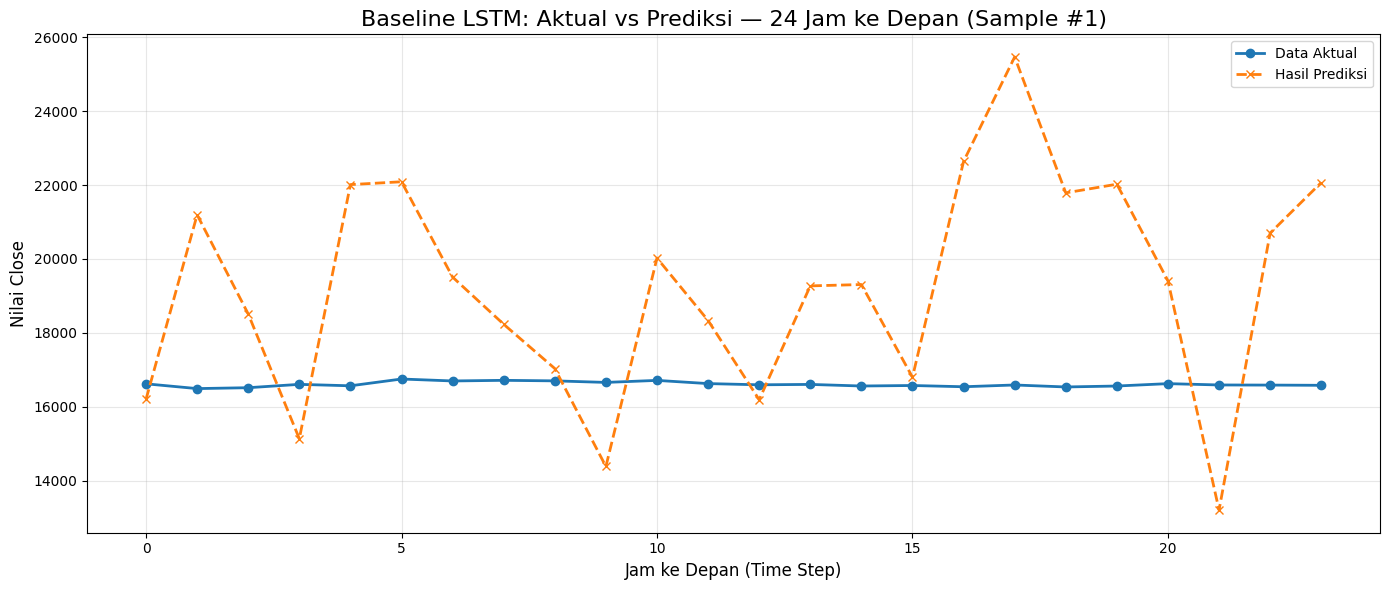

In [27]:
plt.figure(figsize=(14, 6))
plt.plot(range(HORIZON), actual_plot,   marker='o', linewidth=2, label='Data Aktual')
plt.plot(range(HORIZON), baseline_plot, marker='x', linestyle='--',
         linewidth=2, label='Hasil Prediksi')
plt.title(
    f'Baseline LSTM: Aktual vs Prediksi — {HORIZON} Jam ke Depan '
    f'(Sample #{sample_idx+1})', fontsize=16)
plt.xlabel('Jam ke Depan (Time Step)', fontsize=12)
plt.ylabel('Nilai Close', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [28]:
baseline_comparison_df = pd.DataFrame({
    'Jam_ke'        : np.arange(1, HORIZON + 1),
    'Data_Aktual'   : np.round(actual_plot,   2),
    'Hasil_Prediksi': np.round(baseline_plot, 2),
})
baseline_comparison_df['Selisih'] = np.round(
    baseline_comparison_df['Data_Aktual'] - baseline_comparison_df['Hasil_Prediksi'], 2)

print("=" * 55)
print("BASELINE LSTM: Aktual vs Prediksi")
print("=" * 55)
print(baseline_comparison_df.to_string(index=False))

BASELINE LSTM: Aktual vs Prediksi
 Jam_ke  Data_Aktual  Hasil_Prediksi  Selisih
      1     16617.47        16199.87   417.60
      2     16488.41        21193.03 -4704.62
      3     16512.51        18508.53 -1996.02
      4     16603.11        15131.71  1471.40
      5     16564.07        22011.45 -5447.38
      6     16747.83        22088.29 -5340.46
      7     16695.18        19506.10 -2810.92
      8     16712.07        18229.70 -1517.63
      9     16697.69        17030.88  -333.19
     10     16655.80        14379.94  2275.86
     11     16710.50        20022.46 -3311.96
     12     16623.90        18331.63 -1707.73
     13     16590.98        16187.36   403.62
     14     16601.53        19269.27 -2667.74
     15     16558.61        19305.54 -2746.93
     16     16572.11        16797.12  -225.01
     17     16538.45        22638.78 -6100.33
     18     16586.23        25466.60 -8880.37
     19     16532.59        21788.29 -5255.70
     20     16558.11        22022.07 -5463.96


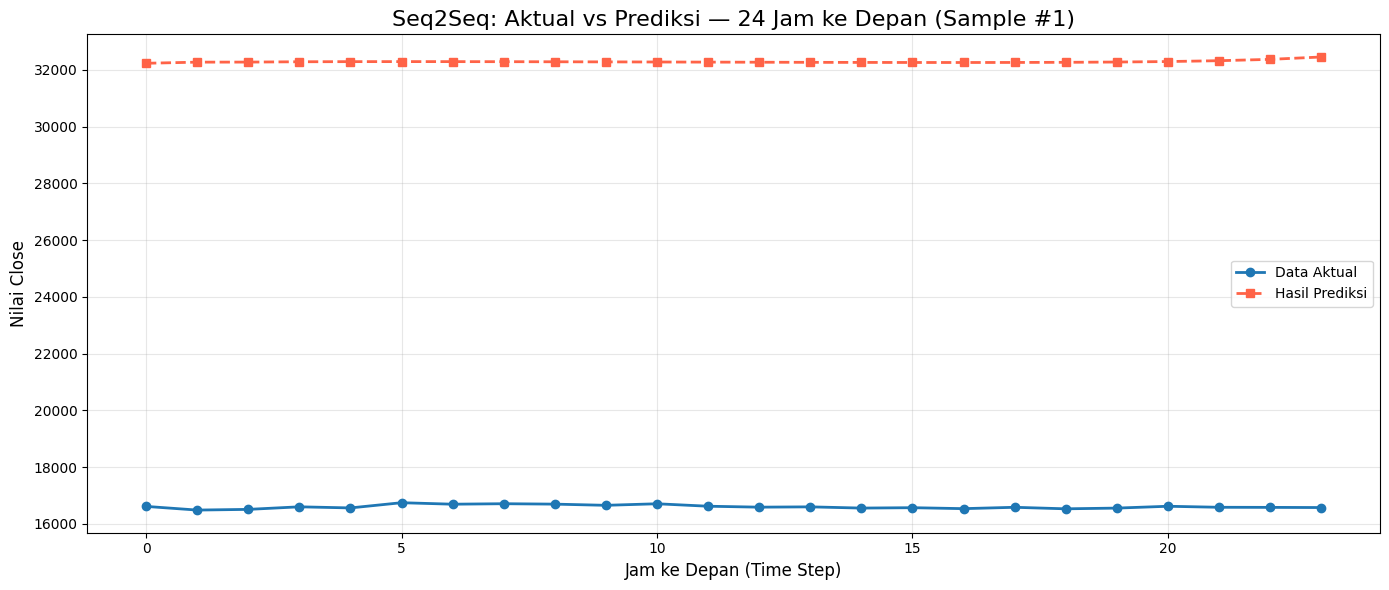

In [29]:
plt.figure(figsize=(14, 6))
plt.plot(range(HORIZON), actual_plot, marker='o', linewidth=2, label='Data Aktual')
plt.plot(range(HORIZON), seq_plot,    marker='s', linestyle='--',
         linewidth=2, label='Hasil Prediksi', color='tomato')
plt.title(
    f'Seq2Seq: Aktual vs Prediksi — {HORIZON} Jam ke Depan '
    f'(Sample #{sample_idx+1})', fontsize=16)
plt.xlabel('Jam ke Depan (Time Step)', fontsize=12)
plt.ylabel('Nilai Close', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [30]:
seq_comparison_df = pd.DataFrame({
    'Jam_ke'        : np.arange(1, HORIZON + 1),
    'Data_Aktual'   : np.round(actual_plot, 2),
    'Hasil_Prediksi': np.round(seq_plot,    2),
})
seq_comparison_df['Selisih'] = np.round(
    seq_comparison_df['Data_Aktual'] - seq_comparison_df['Hasil_Prediksi'], 2)

print("=" * 55)
print("SEQ2SEQ: Aktual vs Prediksi")
print("=" * 55)
print(seq_comparison_df.to_string(index=False))

SEQ2SEQ: Aktual vs Prediksi
 Jam_ke  Data_Aktual  Hasil_Prediksi   Selisih
      1     16617.47        32235.75 -15618.28
      2     16488.41        32275.53 -15787.12
      3     16512.51        32277.56 -15765.05
      4     16603.11        32289.12 -15686.01
      5     16564.07        32293.21 -15729.14
      6     16747.83        32294.80 -15546.97
      7     16695.18        32293.97 -15598.79
      8     16712.07        32291.74 -15579.67
      9     16697.69        32288.57 -15590.88
     10     16655.80        32284.83 -15629.03
     11     16710.50        32280.81 -15570.31
     12     16623.90        32276.73 -15652.83
     13     16590.98        32272.70 -15681.72
     14     16601.53        32269.04 -15667.51
     15     16558.61        32266.00 -15707.39
     16     16572.11        32263.89 -15691.78
     17     16538.45        32263.26 -15724.81
     18     16586.23        32264.78 -15678.55
     19     16532.59        32269.59 -15737.00
     20     16558.11        3227

In [32]:
baseline_scaled_mae = mean_absolute_error(
    y_test.flatten(), baseline_preds.flatten())
seq_scaled_mae = mean_absolute_error(
    y_test.flatten(), seq_preds.flatten())

print("\nMAE BEFORE INVERSE SCALING")
print("=" * 40)
print(f"Baseline Scaled MAE : {baseline_scaled_mae:.6f}")
print(f"Seq2Seq Scaled MAE  : {seq_scaled_mae:.6f}")
print("=" * 40)


MAE BEFORE INVERSE SCALING
Baseline Scaled MAE : 0.065326
Seq2Seq Scaled MAE  : 0.137132


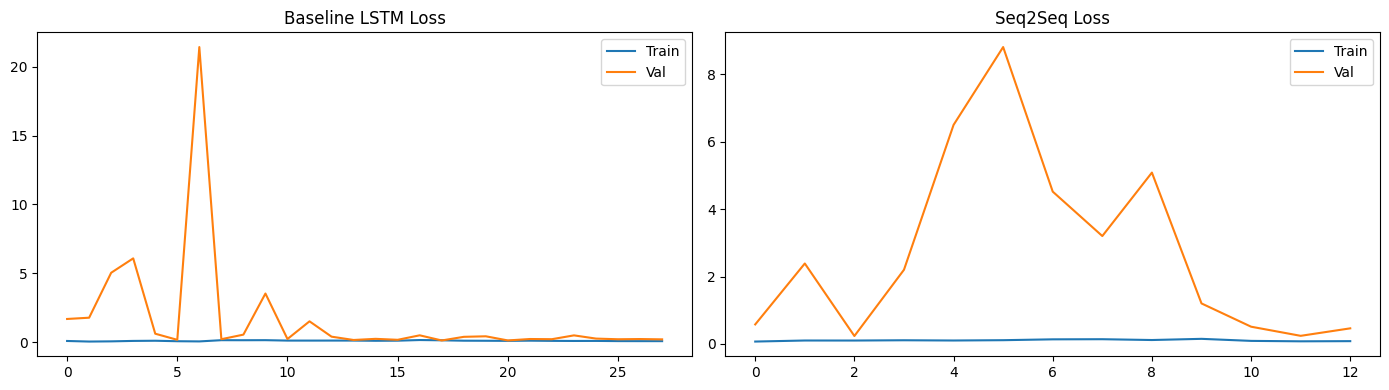

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(train_losses,         label='Train')
axes[0].plot(val_losses,           label='Val')
axes[0].set_title('Baseline LSTM Loss')
axes[0].legend()
axes[1].plot(train_losses_seq_hist, label='Train')
axes[1].plot(val_losses_seq_hist,   label='Val')
axes[1].set_title('Seq2Seq Loss')
axes[1].legend()
plt.tight_layout()
plt.savefig('training_curves.png', dpi=120)
plt.show()

In [34]:
baseline_model.save("model_baseline_LSTM.keras")

print("Baseline model berhasil disimpan.")

Baseline model berhasil disimpan.


In [35]:
seq2seq_model.save("model_seq2seq_LSTM.keras")

print("Seq2Seq model berhasil disimpan.")

Seq2Seq model berhasil disimpan.


In [36]:
seq2seq_model.save("best_model_seq2seq_LSTM.keras")

print("Best Seq2Seq model berhasil disimpan.")

Best Seq2Seq model berhasil disimpan.


In [37]:
baseline_loaded = tf.keras.models.load_model(
    "model_baseline_LSTM.keras",
    custom_objects={
        "BaselineLSTM": BaselineLSTM,
        "CustomMultiHeadAttention": CustomMultiHeadAttention,
        "WeightedMAELoss": WeightedMAELoss
    }
)

In [38]:
!pip freeze > requirements.txt